<a href="https://colab.research.google.com/github/rashmib21/Data-Analysis-of-Stock-Market-from-2016-to-2026/blob/main/high_low.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Install pmdarima if not already installed
try:
    import pmdarima as pm
except ImportError:
    %pip install pmdarima
    import pmdarima as pm

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

# Install odfpy if not already installed, required for engine='odf'
try:
    import odfpy
except ImportError:
    %pip install odfpy

# Step 1: Load the data and initial processing
# Ensure you have 'odfpy' installed for engine='odf': pip install odfpy
try:
    df = pd.read_excel('Hindustan_copper.ods', engine='odf') # Corrected filename
except FileNotFoundError:
    print("Error: 'Hindustan_copper.ods' not found. Please make sure the file is in the correct directory.")
    raise
except Exception as e:
    print(f"An error occurred while loading the ODS file: {e}")
    raise

# Parse datetime column, set as index, sort, and assign business day frequency
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')
df = df.sort_index()
df = df.asfreq('B', method='ffill')

# Step 2: Calculate target series
df['high_low_mean'] = (df['high'] + df['low']) / 2

target_series = df['high_low_mean']

print("Data loaded and preprocessed. First 5 rows of the target series:")
display(target_series.head())

Data loaded and preprocessed. First 5 rows of the target series:


,high_low_mean
datetime,
2016-01-04 00:00:00+05:30,83.150
2016-01-05 00:00:00+05:30,82.275
2016-01-06 00:00:00+05:30,81.275
2016-01-07 00:00:00+05:30,77.750
2016-01-08 00:00:00+05:30,76.675


In [6]:
# Step 3: Split into 80% train and 20% test
train_size = int(len(target_series) * 0.8)
train, test = target_series[0:train_size], target_series[train_size:len(target_series)]

print(f"Train set size: {len(train)}")
print(f"Test set size: {len(test)}")

Train set size: 2136
Test set size: 535


In [7]:
# Step 4: Find the best (p,d,q) order using auto_arima on the train set
print("Finding best ARIMA order using auto_arima...")
model = pm.auto_arima(train,
                      seasonal=False,
                      stepwise=True,
                      suppress_warnings=True,
                      error_action='ignore',
                      trace=False)

best_order = model.order
print(f"Best ARIMA (p,d,q) order found: {best_order}")

Finding best ARIMA order using auto_arima...
Best ARIMA (p,d,q) order found: (0, 1, 1)


In [8]:
# Step 5: Apply walk-forward validation
print("Starting walk-forward validation...")
history = [x for x in train]
predictions = list()

for i, t in enumerate(test):
    model_wf = pm.ARIMA(order=best_order, suppress_warnings=True, error_action='ignore')
    model_wf_fit = model_wf.fit(history)
    yhat = model_wf_fit.predict(n_periods=1)[0]
    predictions.append(yhat)
    history.append(t)

    if (i + 1) % 50 == 0:
        print(f'-> Predicted step {i + 1}/{len(test)}')

print("Walk-forward validation complete.")

# Convert predictions to a pandas Series with test index
predictions_series = pd.Series(predictions, index=test.index)

# Step 6: Calculate and print RMSE
rmse = np.sqrt(mean_squared_error(test, predictions_series))
print(f'RMSE: {rmse:.3f}')

Starting walk-forward validation...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).

-> Predicted step 50/535


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).

-> Predicted step 100/535


...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).

-> Predicted step 500/535


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).

Walk-forward validation complete.
RMSE: 11.612


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['error_action']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


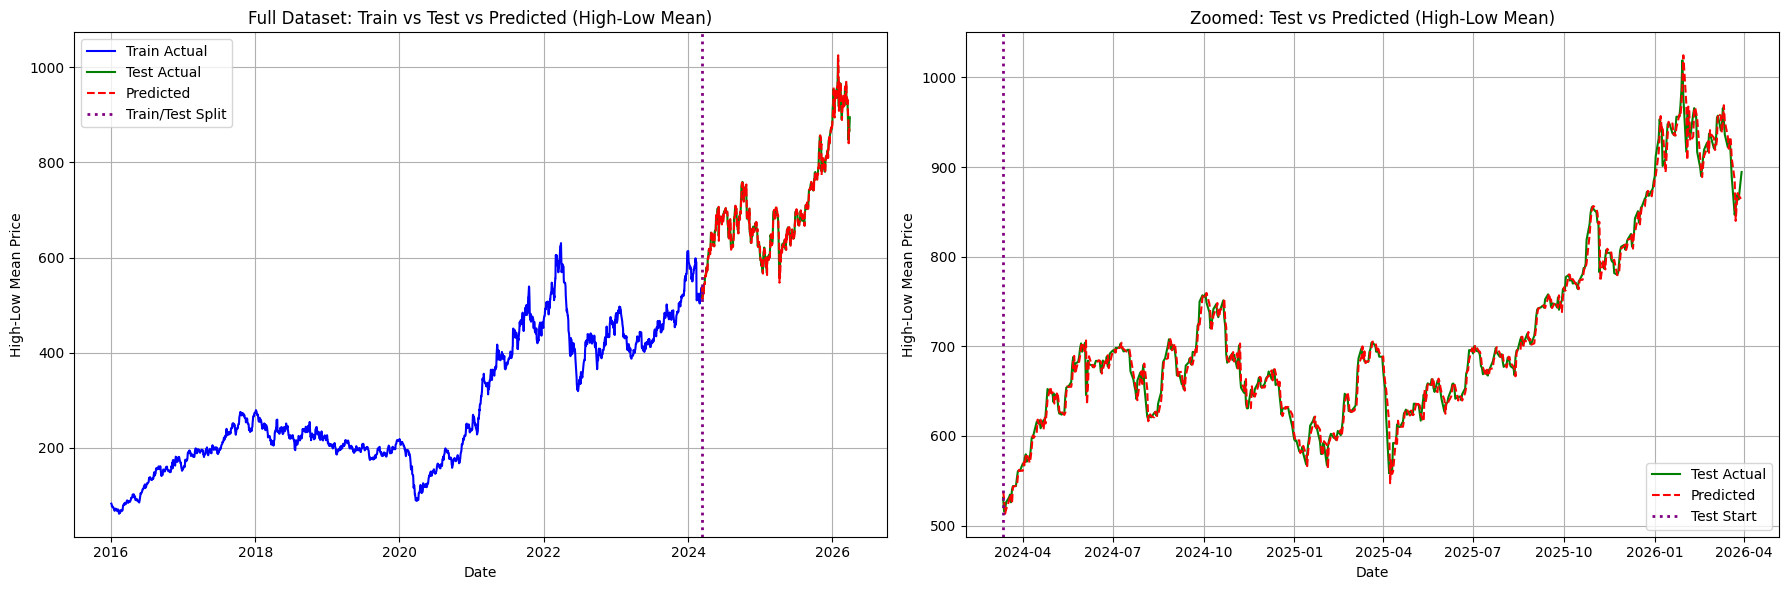


Final ARIMA Order: (0, 1, 1)
Final RMSE: 11.612


In [9]:
# Step 7: Create a figure with 2 subplots
plt.figure(figsize=(18,6))

# Left subplot: Full view
plt.subplot(1, 2, 1)
plt.plot(train.index, train, color='blue', label='Train Actual')
plt.plot(test.index, test, color='green', label='Test Actual')
plt.plot(predictions_series.index, predictions_series, color='red', linestyle='--', label='Predicted')
plt.axvline(x=train.index[-1], color='purple', linestyle=':', linewidth=2, label='Train/Test Split')
plt.title('Full Dataset: Train vs Test vs Predicted (High-Low Mean)')
plt.xlabel('Date')
plt.ylabel('High-Low Mean Price')
plt.legend()
plt.grid(True)

# Right subplot: Zoomed test-only view
plt.subplot(1, 2, 2)
plt.plot(test.index, test, color='green', label='Test Actual')
plt.plot(predictions_series.index, predictions_series, color='red', linestyle='--', label='Predicted')
plt.axvline(x=test.index[0], color='purple', linestyle=':', linewidth=2, label='Test Start')
plt.title('Zoomed: Test vs Predicted (High-Low Mean)')
plt.xlabel('Date')
plt.ylabel('High-Low Mean Price')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal ARIMA Order: {best_order}")
print(f"Final RMSE: {rmse:.3f}")